# Inflation Trends in the United States (2004 – Present)

## Consumer Price Index (CPI) vs. Core CPI Year-over-Year

### Description

This notebook provides a technical visualization of U.S. inflationary trends over the past two decades. Utilizing data retrieved from the Federal Reserve Economic Data (FRED) system, it evaluates and contrasts two primary macroeconomic metrics:

- **Headline CPI (All Urban Consumers | FRED: CPIAUCSL):** Reflects the price changes of a representative basket of goods and services, capturing aggregate consumer price movements.
- **Core CPI (All Items Less Food and Energy | FRED: CPILFESL):** Isolates the structural, long-term inflation trend by stripping away historically volatile food and energy commodity components.

The analysis is conducted using year-over-year (YoY) percentage changes, allowing for a smoothed structural overview of consumer purchasing power and underlying macroeconomic momentum.

---

## Objectives

- **Long-Term Trend Analysis:** Evaluate structural inflation patterns from 2004 through the present day.
- **Metric Variance:** Compare the sensitivity and decoupling behavior of headline inflation versus core inflation during commodity shocks.
- **Macroeconomic Chronology:** Identify and map specific historical periods of structural inflation acceleration (reflation/hyper-demand) and deceleration (disinflation/deflation).
- **Policy Contextualization:** Provide a data-driven timeline mapping inflation fluctuations to Federal Reserve monetary cycles and global economic events.

---

## Data Source

- **Federal Reserve Economic Data (FRED)**  
  - `CPIAUCSL`: Consumer Price Index for All Urban Consumers: All Items  
  - `CPILFESL`: Consumer Price Index for All Urban Consumers: All Items Less Food and Energy  
  - `DPCCRV1A225NBEA`: Personal Consumption Expenditures (PCE) Excluding Food and Energy (chain-type price index)  
  - `PCETRIM12M159SFRBDAL`: Trimmed Mean PCE Inflation Rate

---

## CPI Inflation (2004–Present): Historical Chronology

### Major Macroeconomic Events Impacting Trends:
- **2008 Great Recession & Housing Market Collapse:** Sharp contraction in aggregate demand leading to historical disinflationary/deflationary pressures.
- **2020 COVID-19 Pandemic:** Initial deflationary shock followed by massive global supply-chain disruptions and unprecedented fiscal stimulus.
- **2021–2023 Post-Pandemic Inflationary Surge:** A historic peak in global inflation driven by surging consumer demand, structural labor shortages, and energy market imbalances.
- **2022–2024 Fed Monetary Tightening Cycle:** Aggressive interest rate hikes enacted by the Federal Reserve to cool demand and anchor long-term inflation expectations back to the 2.0% target.
- **Global Geopolitical Friction (2022–Present):** Supply chain friction and commodity shocks amplified by the Russia-Ukraine war and escalating conflicts in the Middle East.

## Pre-Processing

### Install System Dependencies

In [1]:
!pip install pandas-datareader
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip

### Import Python Libraries

In [2]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.transforms as transforms
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Define Global Functions 

In [ ]:
def add_event_lines(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=10,
                     fontweight='bold')
            
def add_event_lines_small(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=5,
                     fontweight='bold')
            
def add_event_lines_large(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=15,
                     fontweight='bold')

### Standard Unit Initial Timeframe

In [4]:
start = datetime(2005, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

## CPI Inflation: 20-Year Historical

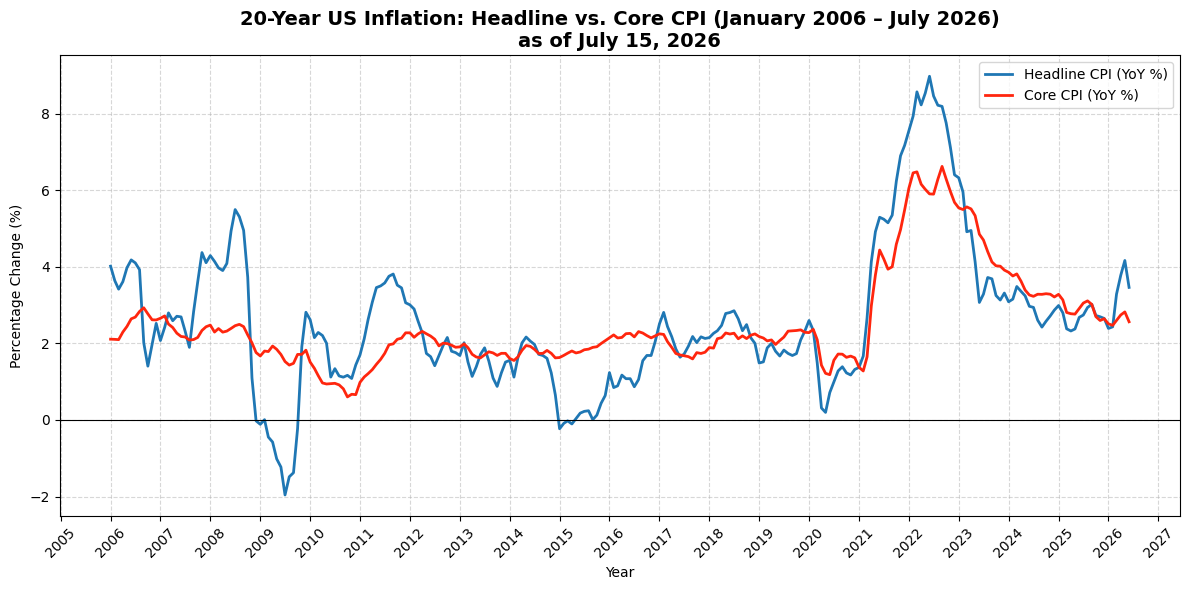

In [5]:
cpi_series = {
'CPIAUCSL': 'CPI for All Urban Consumers: All Items', 
'CPILFESL': 'CPI for All Urban Consumers: All Items Less Food and Energy'
}

df = web.DataReader(list(cpi_series.keys()), 'fred', start, end)
df.rename(columns=cpi_series, inplace=True)
df = df.ffill()

df_yoy = df.pct_change(periods=12) * 100

plt.figure(figsize=(12, 6))

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items'],
        label='Headline CPI (YoY %)', 
        color='#1f77b4', 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items Less Food and Energy'],
        label='Core CPI (YoY %)', 
        color="#ff260e", 
        linewidth=2)

y = plt.ylim()[1]*0.85

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# plot formatting
plt.title(f'20-Year US Inflation: Headline vs. Core CPI ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

## 10-Year Historical Index
- 2008 Finanical Housing Crisis
- COVID-19 Pandemic
- Start of Iran War

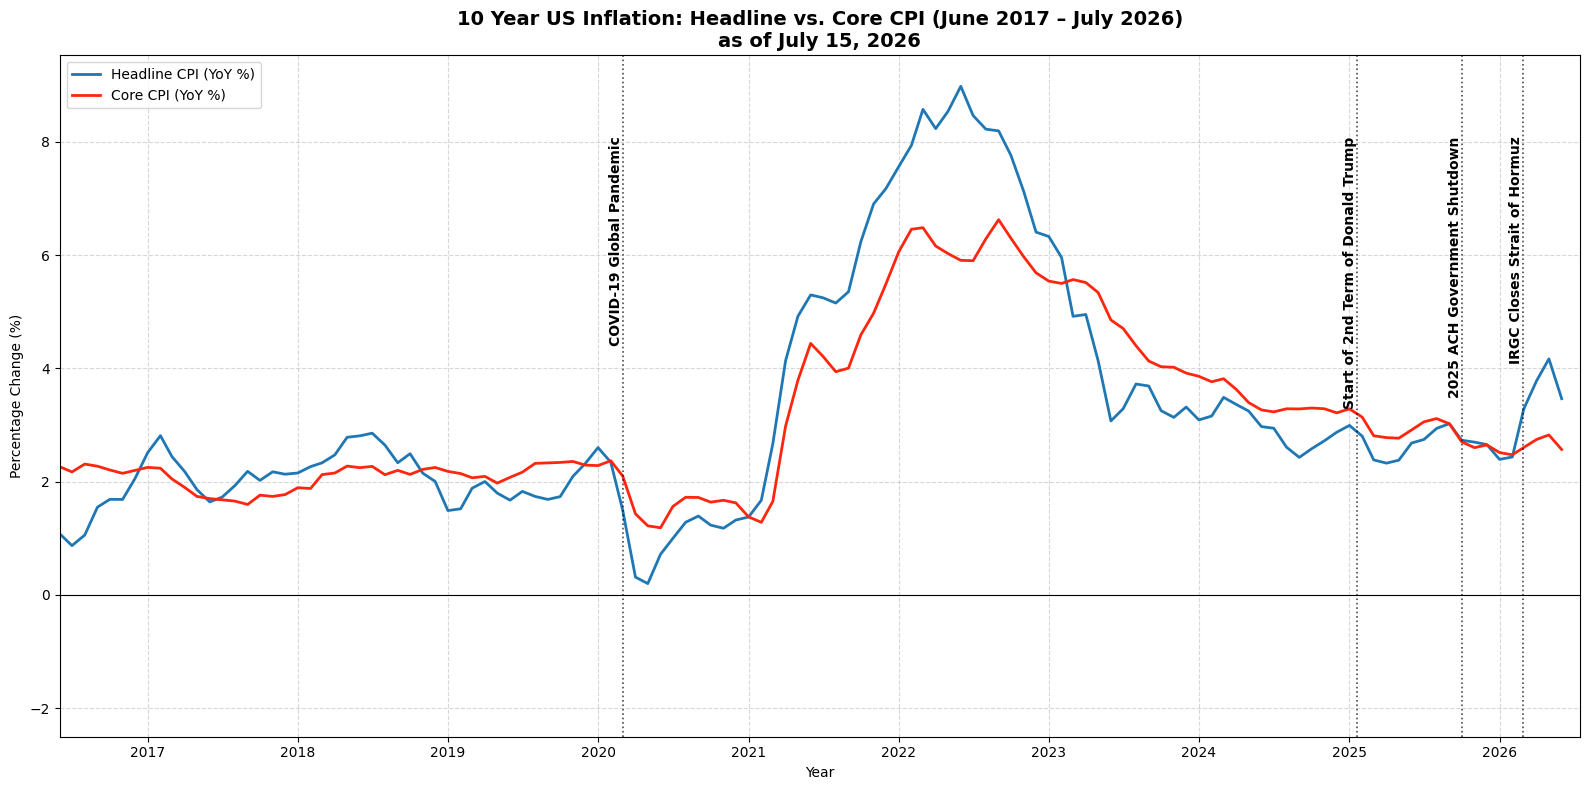

In [52]:
# timeframe
start = datetime(2016, 6, 1)

plot_start = start + relativedelta(years=1)

plt.figure(figsize=(16, 8))

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items'],
        label='Headline CPI (YoY %)', 
        color='#1f77b4', 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items Less Food and Energy'],
        label='Core CPI (YoY %)', 
        color="#ff260e", 
        linewidth=2)

y = plt.ylim()[1]*0.85

events = {
'2007-12-01': '2008 U.S. Housing Crisis Recession',
'2020-03-01': 'COVID-19 Global Pandemic',
'2025-01-20': 'Start of 2nd Term of Donald Trump',
'2025-10-01': '2025 ACH Government Shutdown',
'2026-02-28': 'IRGC Closes Strait of Hormuz'
}

# plot formatting
plt.title(f'10 Year US Inflation: Headline vs. Core CPI ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlim(start,end)
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
add_event_lines(events , df, y)
plt.legend()
plt.tight_layout()

plt.show()

## CPI Inflation (July 2020-Present)
### Key Events
- Presidential Inauguration of Donald J. Trump's as the 47th President of the United States of America.
- Effective start of President Trump's global tariffs policy.
- U.S. Congressional 43-day shutdown.
- Iran closed the Straight of Hormuz.

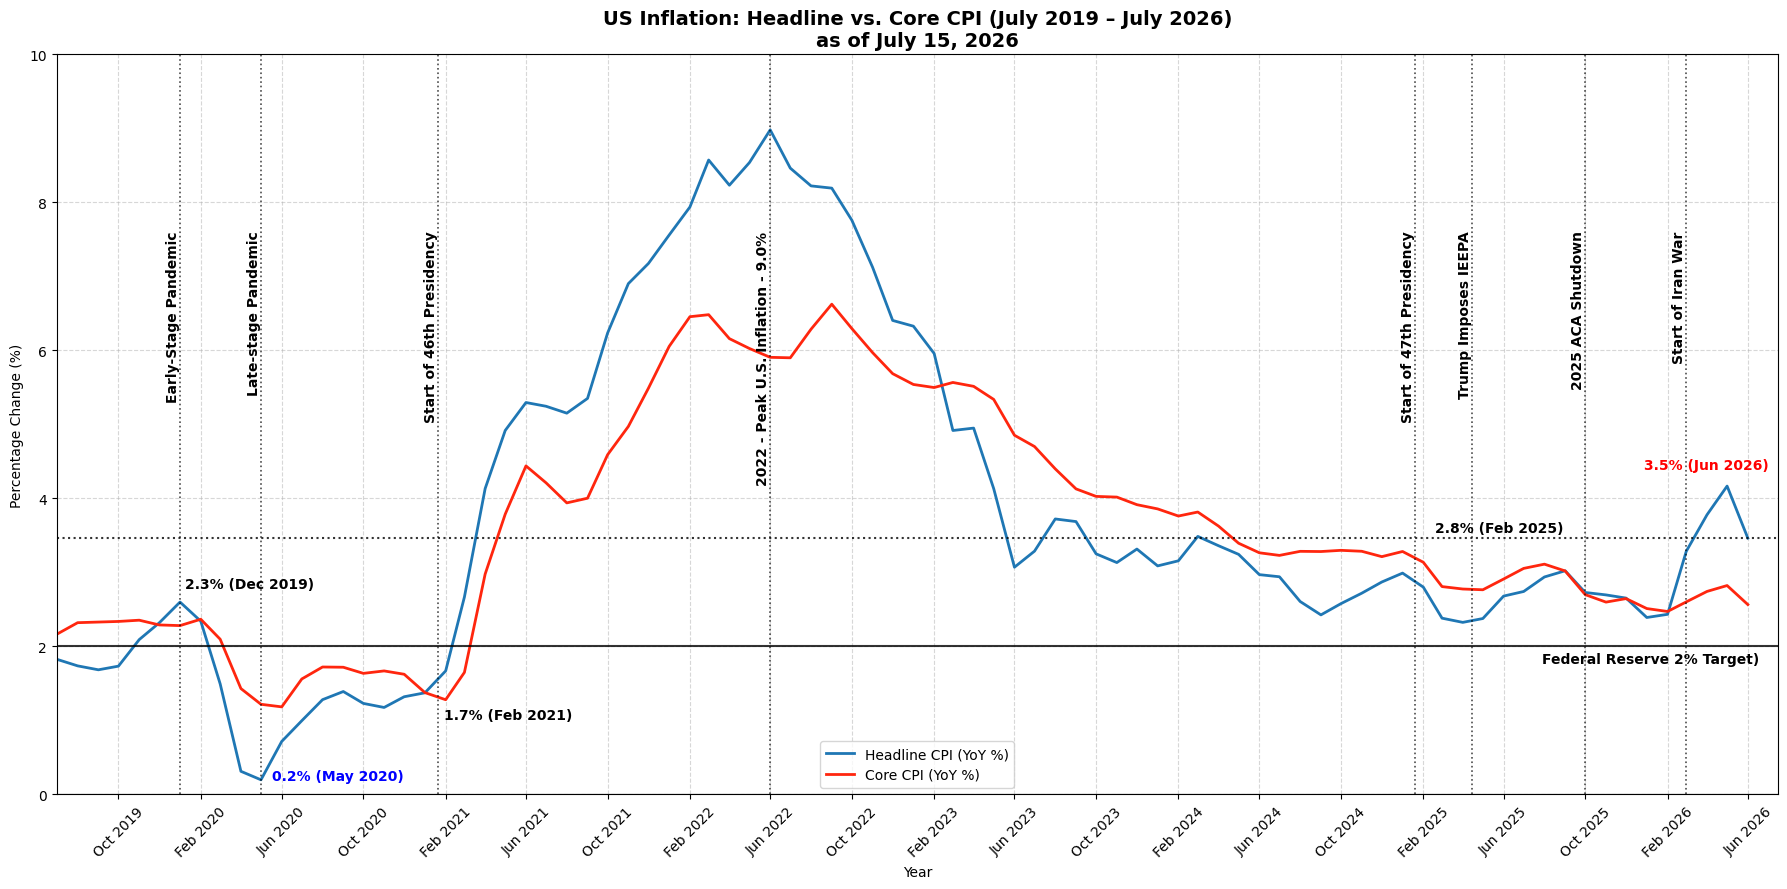

In [50]:
events = {
'2025-01-20': 'Start of 47th Presidency',
'2025-4-15': 'Trump Imposes IEEPA',
'2025-10-01': '2025 ACA Shutdown',
'2026-02-28': 'Start of Iran War',
'2020-01-01': 'Early-Stage Pandemic',
'2020-05-01': 'Late-stage Pandemic',
'2021-01-20': 'Start of 46th Presidency',
'2022-06-01': '2022 - Peak U.S. Inflation - 9.0%'
}

# Present values
r_date = df_yoy['CPI for All Urban Consumers: All Items'].dropna().index[-1]
r_val = df_yoy['CPI for All Urban Consumers: All Items'].dropna().iloc[-1]

# Pandemic Start
p_date = df_yoy['CPI for All Urban Consumers: All Items'].dropna().index[-74]
p_val = df_yoy['CPI for All Urban Consumers: All Items'].dropna().iloc[-74]

# Pre-Pandemic Peak
c_date = df_yoy['CPI for All Urban Consumers: All Items'].dropna().index[-79]
c_val = df_yoy['CPI for All Urban Consumers: All Items'].dropna().iloc[-79]

# 46th President
x1_date = df_yoy['CPI for All Urban Consumers: All Items'].dropna().index[-65]
x1_val = df_yoy['CPI for All Urban Consumers: All Items'].dropna().iloc[-65]

# 47th President
x2_date = df_yoy['CPI for All Urban Consumers: All Items'].dropna().index[-17]
x2_val = df_yoy['CPI for All Urban Consumers: All Items'].dropna().iloc[-17]

# timeframe
start = datetime(2019, 7, 1)
plot_start = start + relativedelta(years=1)

# Plot
plt.figure(figsize=(18, 9))

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items'],
        label='Headline CPI (YoY %)', 
        color='#1f77b4', 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items Less Food and Energy'],
        label='Core CPI (YoY %)', 
        color="#ff260e", 
        linewidth=2)

y = plt.ylim()[1]*0.8

# Formatting
plt.title(f'US Inflation: Headline vs. Core CPI ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlim(start, end)
plt.ylim(0,10)
ax = plt.gca() # Get current axes object

# Mnnthl-by-month axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
plt.xticks(rotation=45)

add_event_lines(events, df, y)
plt.annotate(f"{r_val:.1f}% ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-30,50), 
             ha = 'center', 
             weight = 'bold', 
             color = 'red')
plt.annotate(f"{p_val:.1f}% ({p_date.strftime('%b %Y')})", 
             (p_date, p_val), 
             textcoords = "offset points", 
             xytext = (55,0), 
             ha = 'center', 
             weight = 'bold', 
             color = 'blue')
plt.annotate(f"{c_val:.1f}% ({c_date.strftime('%b %Y')})", 
             (c_date, c_val), 
             textcoords = "offset points", 
             xytext = (65,25), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.annotate(f"{x1_val:.1f}% ({x1_date.strftime('%b %Y')})", 
             (x1_date, x1_val), 
             textcoords = "offset points", 
             xytext = (45,-35), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.annotate(f"{x2_val:.1f}% ({x2_date.strftime('%b %Y')})", 
             (x2_date, x2_val), 
             textcoords = "offset points", 
             xytext = (55,40), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.annotate(f"Federal Reserve 2% Target)", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-70,-90), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.axhline(y=r_val, 
            color="#000000", 
            linestyle=':', 
            linewidth=1.5, 
            alpha=0.8)
plt.axhline(y=2, 
            color="#000000", 
            linestyle='-', 
            linewidth=1.5, 
            alpha=0.8)


plt.legend()
plt.tight_layout()

plt.show()

## Personal Consumption Expenditures (PCE)

### Real Personal Consumption Expenditures Per Capita: 10-Year Historical 

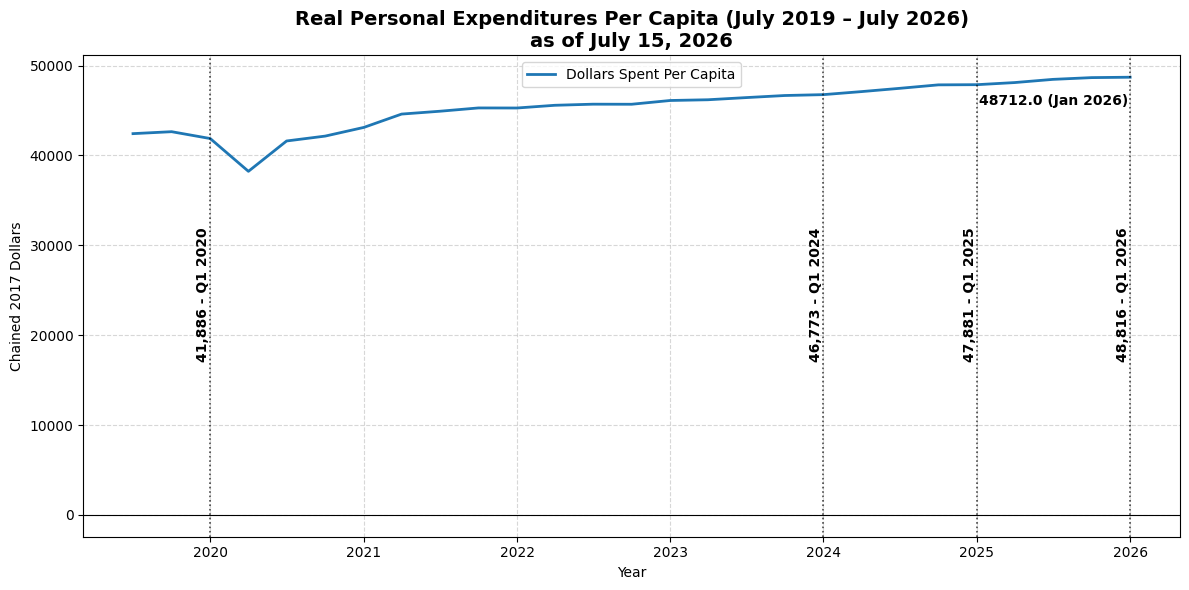

In [8]:
# source: FRED
df = web.DataReader('A794RX0Q048SBEA', 'fred', start, end)

# values
r_date = df['A794RX0Q048SBEA'].dropna().index[-1]
r_val = df['A794RX0Q048SBEA'].dropna().iloc[-1]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['A794RX0Q048SBEA'], 
         label="Dollars Spent Per Capita", 
         color='#1f77b4', 
         linewidth=2)

y = plt.ylim()[1]*0.65



# Q1 2016-2026
fyq_s1 = {
    '2016-01-1': '39,667 - Q1 2016',
    '2020-01-1': '41,886 - Q1 2020',
    '2024-01-1': '46,773 - Q1 2024',
    '2025-01-1': '47,881 - Q1 2025',
    '2026-01-1': '48,816 - Q1 2026'
}

plt.title(f'Real Personal Expenditures Per Capita ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Chained 2017 Dollars')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
add_event_lines(fyq_s1, df, y)
plt.annotate(f"{r_val:.1f} ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-55,-20), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.legend()
plt.tight_layout()

plt.show()

### Consumer Price Index for All Urban Consumers: 5-Year Historical

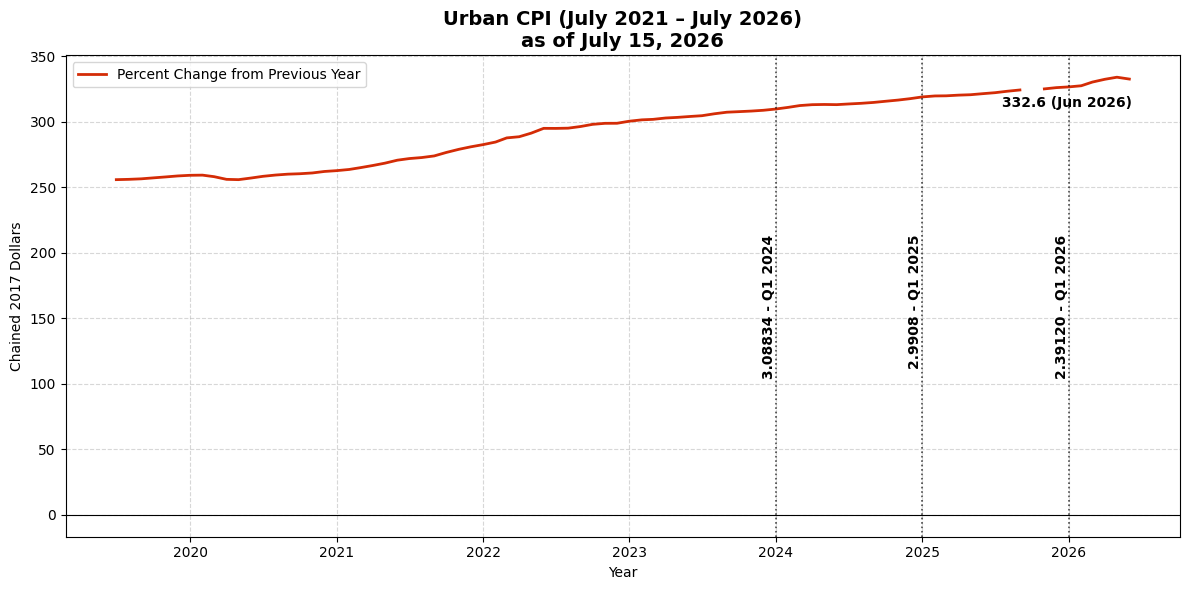

In [9]:
# source
df = web.DataReader('CPIAUCSL', 'fred', start, end)

# values
r_date = df['CPIAUCSL'].dropna().index[-1]
r_val = df['CPIAUCSL'].dropna().iloc[-1]

# timeframe
start = datetime(2021, 7, 1)
plot_start = start + relativedelta(years=1)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['CPIAUCSL'], 
         label="Percent Change from Previous Year", 
         color="#d42c06", 
         linewidth=2)

y = plt.ylim()[1]*0.5

# Event Markers
fyq_s2 = {
    '2024-01-1': '3.08834 - Q1 2024',
    '2025-01-1': '2.9908 - Q1 2025',
    '2026-01-1': '2.39120 - Q1 2026'
}

plt.title(f'Urban CPI ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Chained 2017 Dollars')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
add_event_lines(fyq_s2, df, y+45)
plt.annotate(f"{r_val:.1f} ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-45,-20), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')


plt.show()

### Trimmed Mean PCE and PCE Inflation Rate: 5-Year Historical 

/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_35589/1856337052.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_rate['PCE Rate Excluding Food and Energy'] = df_raw['PCE Inflation Rate Excluding Food and Energy'].pct_change(12) * 100


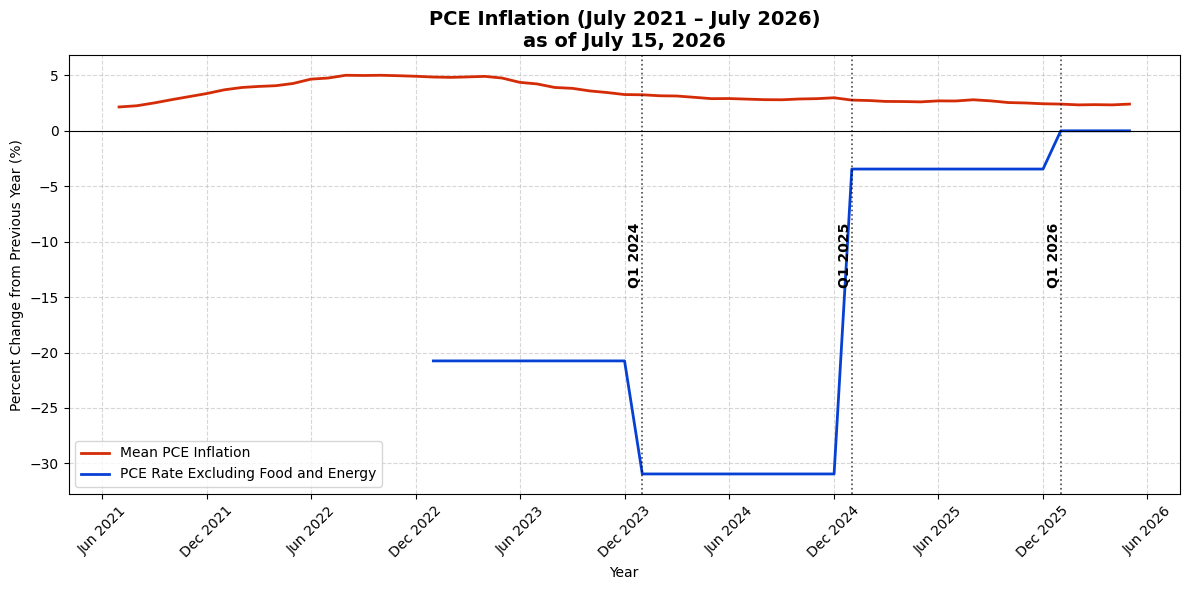

In [10]:
rate_series = {
    'PCETRIM12M159SFRBDAL': 'Trimmed Mean PCE Inflation Rate',
    'DPCCRV1A225NBEA': 'PCE Inflation Rate Excluding Food and Energy',
}

df_raw = web.DataReader(list(rate_series.keys()), 'fred', start, end)
df_raw.rename(columns=rate_series, inplace=True)

df_rate = pd.DataFrame()
df_rate['Trimmed Mean PCE Inflation Rate'] = df_raw['Trimmed Mean PCE Inflation Rate']
df_rate['PCE Rate Excluding Food and Energy'] = df_raw['PCE Inflation Rate Excluding Food and Energy'].pct_change(12) * 100

start = datetime(2021, 7, 1)
plot_start = start + relativedelta(years=1)

plt.figure(figsize=(12, 6))
plt.plot(df_rate.index, 
         df_rate['Trimmed Mean PCE Inflation Rate'], 
         label="Mean PCE Inflation", 
         color="#d42c06", 
         linewidth=2)

plt.plot(df_rate.index, df_rate['PCE Rate Excluding Food and Energy'], 
         label="PCE Rate Excluding Food and Energy", 
         color="#0640d4", 
         linewidth=2)

y = plt.ylim()[1]*0.25

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Event Markers
fyq_s3 = {
    '2024-01-1': 'Q1 2024',
    '2025-01-1': 'Q1 2025',
    '2026-01-1': 'Q1 2026'
}

plt.title(f'PCE Inflation ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percent Change from Previous Year (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
add_event_lines(fyq_s3,df,y-10)

plt.show()

# Conclusions and Observations


### Inflation – 12 June 2026

Consumer prices rose 4.2% annually in May marking the highest year-over-year increase since April 2023. Contributing factors to economic conditions in April 2023 included post-pandemic supply chain restarts, Russia’s invasion of Ukraine, elevated housing and shelter costs, massive rehiring waves, and higher demands for goods and services.

Today the issues are rising fuel and energy costs, tariff policies, the ~~Iran War~~ ceasefire over control of the Strait of Hormuz, static housing costs, and rapid expansion of artificial intelligence data centers.

***You read that correctly.***

April 2023 was wrought with egg prices at $3.27/ dozen and gas at $3.60/ gallon, up from $2.52/ dozen and down from $4.11/ gallon the previous year, marking ~30% increase and -12.4% decrease respectively.

In May 2026, beef and coffee prices are $6.75/ pound and $9.51/ pound, up from up from $6.02/ pound and $8.09/ pound, respectively. Gas prices in May 2026 were $4.48/ gallon, up from $3.15/ gallon the previous year. Marking a whopping 13%, 17.5%, and 40.5% increase from May 2025.

Americans were hit hard by these developments, costing taxpayers $17.76 billion dollars more over the year, whereas taxpayers paid just $5.28 billion more for eggs and gas in 2023. Then, in the aftermath of a devasting worldwide illness, inflation sat at a tentative 4.9%.

***Today, inflation is 4.2%, and it’s not done growing.***

The Producer Price Index measures inflations in wholesale before goods and services ever reach consumers. How much the producer pays has direct impacts into consumer costs. This is where the results are stark. 

In April 2023, the headline PPI in the United states actually fell 0.2% from the previous month, which demonstates tha producers were paying marginally more to produce.

In May 2026, PPI rose 1.1% from the previous month. 

**The annualized rate of PPI reached 6.5% in May 2026, marking the highest in 4 years, since November 2022, during the fall of peak post-pandemic inflation.**

The United Statts is heading in the wrong direction. Where that direction is pointed, I’m not even sure any human being is able to reach on its own without fully detaching itself from its biological structure. 

Wage growth since 2025 was massive win for the nations leadership, and in just a brief 2-month span, that growth has completely evaporated. But the land persists.

We are in a war and we don’t like it. We’re paying extra on goods this country depends on, and we don’t like it. We’re waist-deep in over-hyped industrialism, and we don’t like it. 

*So we deal it it. We put up with it. Until the day arrives, where we can reason with the circumstances, quash it, and return to the natural order of things.*

<u>Take a hike. Expect a rate change. Today is not that day.</u>

---

**Thank you for reading, the Healthcare Consumer Price Index was also updated today, go ahead and check that out. While you're at it, grab some lunch.**

---


### Editor's Note:

1. The Federal Reserve released their FOMC on June 17, 2024, this analyis was written preceeding this decision.
2. Obesrvations regarding the rate decsion will be adressed in the next analysis following CPI updates in July 2026.
3. Producers indices and related indices will be included in the next update.

#### Update Schedule

- ***Producer Price Index (PPI) - Jul 15, 2026***
    1. `PPIACO`: **All Commodities**
    2. `PPIFIS`: **By Commodity: Final Demand**
    3. `PCUOMFGOMFG`: **By Industry: Total Manufacturing Industries**
    4. **By Commodity:**
        - `WPS081`: Lumber and Wood Products: Lumber
        - `WPS061`: Chemicals and Allied Products: Industrial Chemicals
        - `WPS101`: Metals and Metal Products: Iron and Steel 
        - `WPSFD49207`: Final Demand: Finished Goods
        - `WPSFD4131`: Final Demand: Finished Goods Less Foods and Energy
    
    5. **By Industry:**
        - `PCU325325`: Chemical Manufacturing
        - `PCU325311325311`: Nitrogenous Fertilizer Manufacturing
        - `PCU335311335311`: Electric Power and Specialty Transformer Manufacturing
        - `PCU33443344`: Semiconductor and Other Electronic Component Manufacturing
        - `PCU3364133641`: Aerospace Product and Parts Manufacturing
        - `PCU325211325211`: Plastics Material and Resin Manufacturing
        - `PCU484121484121`: General Freight Trucking, Long-Distance Truckload
        - `PCU3272132721`: Glass and Glass Product Manufacturing
        - `PCU311311`: Food Manufacturing
        - `PCU32543254`: Pharmaceutical and Medicine Manufacturing
        - `PCU33913391`: Medical Equipment and Supplies Manufacturing
        - `PCU334334`: Computer and Electronic Product Manufacturing 
        - `PCU9241269241262`: Premiums for Homeowner's Insurance
        - `PCU333132333132`: Oil and Gas Field Machinery and Equipment Manufacturing

#### Data Changelog / Notes

#### ***Next review and analysis publishing on Friday, July 10, 2026, at 1:30 P.M. Pacific Time.***